# 8 — M3C 3-φ: Pré-Carga dos Capacitores + Partida Segura do Motor

> **Objetivo**: simular um startup **realista** do M3C, partindo
> dos capacitores **descarregados (≈ 100 V)** e acionando o motor
> só depois que os caps atingiram o nível nominal. É o que acontece
> num drive industrial real ao energizar o conversor pela primeira
> vez.

## Por que pré-carga é essencial

Em um M3C real, não dá pra simplesmente ligar o sistema com os
caps em zero:

1. **Os módulos não conseguem produzir tensão** se os caps estão
   descarregados — qualquer V_xy comandado pelo SVM seria
   essencialmente 0 V.
2. **A entrada injetaria corrente de inrush enorme** tentando
   carregar os caps através das chaves.
3. **O controle de corrente DBPC opera assumindo V_cap nominal**;
   com caps em 100 V, as "unidades" da SVM ficam ~240× menores
   e o controle perde eficácia.

## Sequência proposta — Máquina de Estados (FSM)

A FSM tem 3 estados, transitando sob condições explícitas:

```
┌──────────────────┐  V_mean ≥ 0.9·V_target   ┌──────────────────┐
│   PRECHARGE      │ ─────────────────────────►│   STABILIZING    │
│ • i_out = 0      │                           │ • i_out = 0      │
│ • i_in = 30 A    │                           │ • i_in = 30 A    │
│ • cap-PI off     │                           │ • cap-PI off     │
└──────────────────┘                           │ • timer rodando  │
                                               └──────────────────┘
                                                        │
                                  hold ≥ stabilize_time │
                                                        ▼
                                               ┌──────────────────┐
                                               │   RUNNING        │
                                               │ • i_out = ramp() │
                                               │ • i_in = cap-PI  │
                                               │ • cap-PI ATIVA   │
                                               └──────────────────┘
```

Sem retorno a PRECHARGE em condições normais (só se cair abaixo da
banda de histerese durante STABILIZING).


In [1]:
import sys, os
from pathlib import Path
_HERE = Path.cwd() / "projects" / "inverters" / "m3c_3phase"
if str(_HERE) not in sys.path:
    sys.path.insert(0, str(_HERE))

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 100

In [2]:
import time
from m3c_3phase_model import (
    M3cParams, build_l1_plant,
    run_l1_dbpc_with_precharge, M3cPrechargeConfig,
    make_freq_ramp_abc_ref,
)

params = M3cParams()
print(f"M3C Tab 16 — startup cold (V_cap = 0)")
print(f"  Cap nominal target: {params.v_cap_total_per_module/1000:.0f} kV/módulo")
print(f"  9 módulos × {params.v_cap_total_per_module/1000:.0f} kV = "
        f"{9*params.v_cap_total_per_module/1000:.0f} kV total")


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


M3C Tab 16 — startup cold (V_cap = 0)
  Cap nominal target: 24 kV/módulo
  9 módulos × 24 kV = 216 kV total


## 8.1 — Configurar pré-carga e perfil do motor


In [3]:
precharge_cfg = M3cPrechargeConfig(
    v_cap_initial=100.0,                 # caps quase zero (100 V cada)
    i_d_in_precharge=30.0,               # 30 A de carga (lento e seguro)
    v_cap_release_threshold_frac=0.90,   # libera output em 90% = 21.6 kV
    stabilize_time=0.3,                  # 300 ms para confirmar estabilidade
)

# Motor profile: arranca em rampa de 2 s a 4 s (depois da precharge).
T_RAMP_START = 2.0
T_RAMP_END = 4.0
F_OUT_MAX = 60.0
T_END = 5.5

i_out_ref = make_freq_ramp_abc_ref(
    amplitude=100.0, f_start=0.0, f_end=F_OUT_MAX,
    t_ramp_start=T_RAMP_START, t_ramp_end=T_RAMP_END,
)

print(f"Pré-carga:")
print(f"  V_cap inicial:  {precharge_cfg.v_cap_initial:.0f} V")
print(f"  i_in precharge: {precharge_cfg.i_d_in_precharge:.0f} A")
print(f"  Threshold:      {precharge_cfg.v_cap_release_threshold_frac*100:.0f}% = "
        f"{precharge_cfg.v_cap_release_threshold_frac*params.v_cap_total_per_module/1000:.1f} kV")
print(f"  Stabilize:      {precharge_cfg.stabilize_time*1000:.0f} ms")
print(f"\nMotor: rampa 0 → {F_OUT_MAX} Hz em [{T_RAMP_START}, {T_RAMP_END}] s")
print(f"Total simulação: {T_END} s")


Pré-carga:
  V_cap inicial:  100 V
  i_in precharge: 30 A
  Threshold:      90% = 21.6 kV
  Stabilize:      300 ms

Motor: rampa 0 → 60.0 Hz em [2.0, 4.0] s
Total simulação: 5.5 s


## 8.2 — Rodar a simulação completa


In [4]:
plant = build_l1_plant(params)
t0 = time.time()
result, ctrl, cap, fsm = run_l1_dbpc_with_precharge(
    plant, params,
    i_out_ref_fn=i_out_ref,
    precharge_config=precharge_cfg,
    t_end=T_END, dt=25e-6,
)
elapsed = time.time() - t0
print(f"Simulação concluída em {elapsed:.1f} s wall.")
print(f"\nResultado da FSM:")
print(f"  Threshold reached at: {fsm.threshold_first_reached_at:.3f} s")
print(f"  Released to RUNNING:  {fsm.released_at:.3f} s")
print(f"  Final state:          {fsm.state}")
print(f"\nCapacitores ao final:")
print(f"  V_mean:    {np.mean(ctrl.v_caps_module):.0f} V "
        f"(target {params.v_cap_total_per_module:.0f} V)")
print(f"  V_spread:  {max(ctrl.v_caps_module)-min(ctrl.v_caps_module):.0f} V")


Simulação concluída em 21.0 s wall.

Resultado da FSM:
  Threshold reached at: 1.048 s
  Released to RUNNING:  1.349 s
  Final state:          running

Capacitores ao final:
  V_mean:    24002 V (target 24000 V)
  V_spread:  1033 V


## 8.3 — Figura 1: timeline completo

5 paineis empilhados:
1. **Estado da FSM** (precharge / stabilizing / running).
2. **V_cap mean(t)**: rampa de carga + estabilização + steady-state.
3. **Frequência de saída** (zero durante precharge, depois ramp).
4. **Corrente de entrada** (constante na precharge, ondulando depois).
5. **Corrente de saída** (zero na precharge, motor depois).


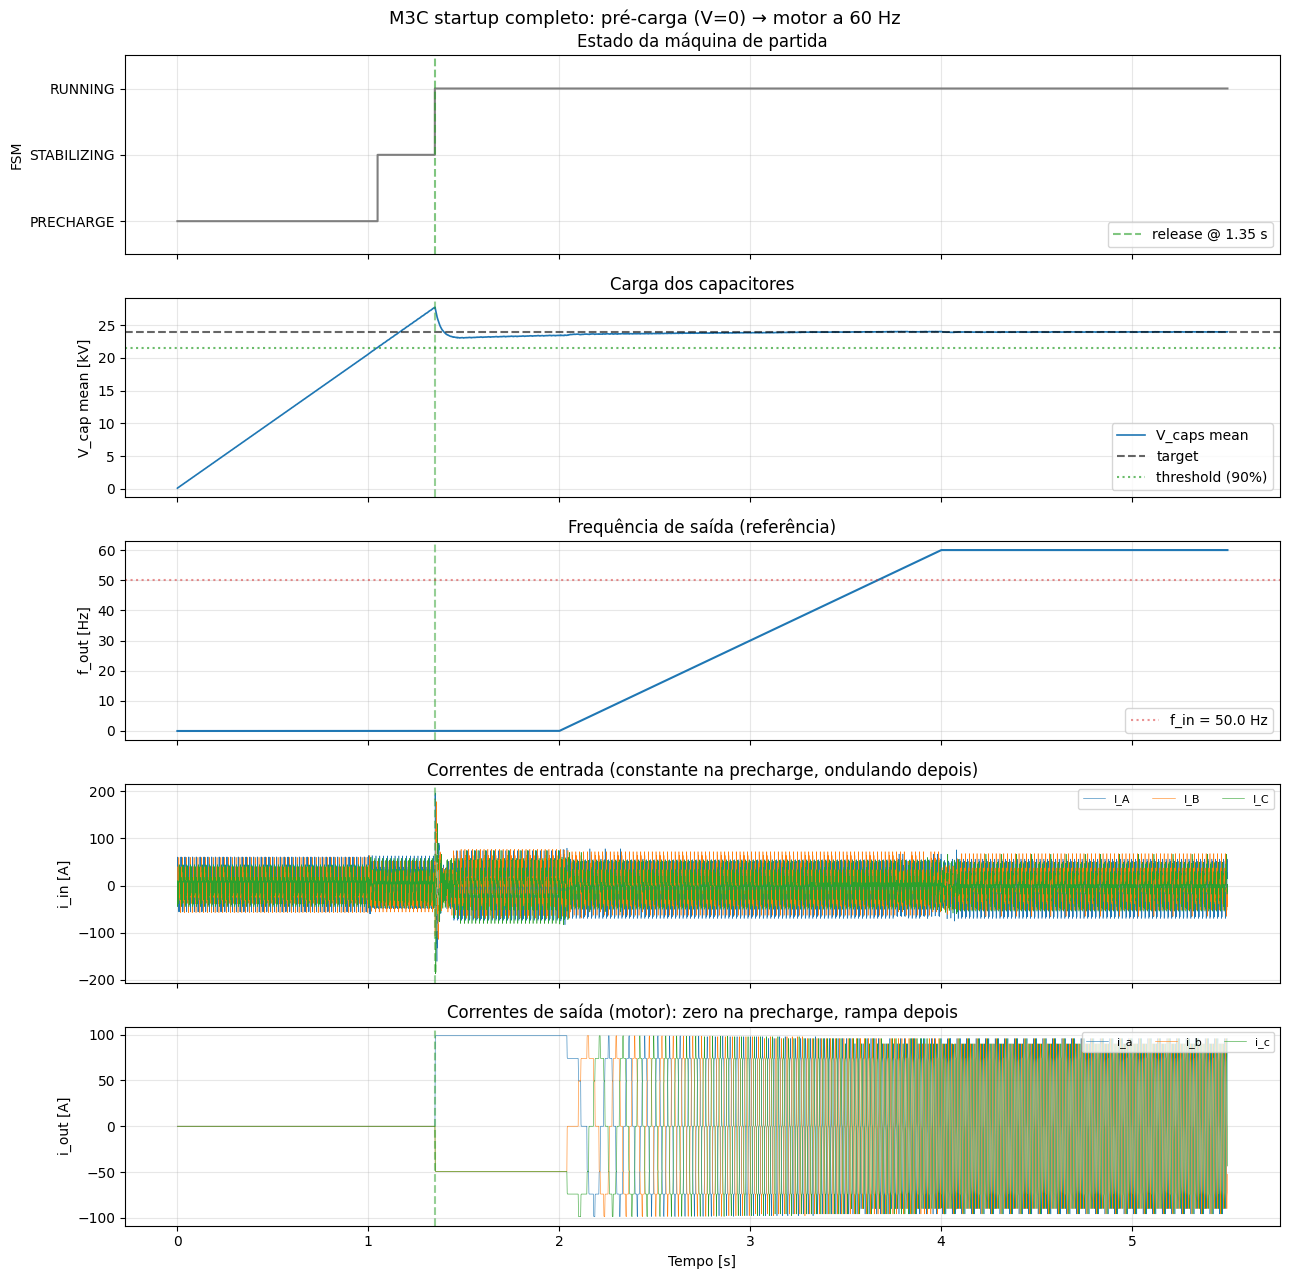

In [5]:
v_hist = np.array(ctrl.v_caps_module_history)
t_caps = np.array(ctrl.refresh_t_centres)
target = params.v_cap_total_per_module

# FSM state as numeric for plotting.
state_map = {"precharge": 0, "stabilizing": 1, "running": 2}
state_num = np.array([state_map[s] for s in fsm.history_state])
t_fsm = np.array(fsm.history_t)

fig, axes = plt.subplots(5, 1, figsize=(13, 13), sharex=True)
fig.suptitle("M3C startup completo: pré-carga (V=0) → motor a 60 Hz",
                fontsize=13)

# Panel 1: FSM state.
axes[0].step(t_fsm, state_num, "C7", where="post", linewidth=1.5)
axes[0].axvline(fsm.released_at, color="C2", linestyle="--", alpha=0.6,
                label=f"release @ {fsm.released_at:.2f} s")
axes[0].set_yticks([0, 1, 2])
axes[0].set_yticklabels(["PRECHARGE", "STABILIZING", "RUNNING"])
axes[0].set_ylim(-0.5, 2.5)
axes[0].set_ylabel("FSM")
axes[0].set_title("Estado da máquina de partida")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# Panel 2: cap mean over time.
v_mean = v_hist.mean(axis=1)
axes[1].plot(t_caps, v_mean/1000, "C0", linewidth=1.2, label="V_caps mean")
axes[1].axhline(target/1000, color="k", linestyle="--", alpha=0.6, label="target")
axes[1].axhline(
    precharge_cfg.v_cap_release_threshold_frac*target/1000,
    color="C2", linestyle=":", alpha=0.7,
    label=f"threshold ({int(precharge_cfg.v_cap_release_threshold_frac*100)}%)",
)
axes[1].axvline(fsm.released_at, color="C2", linestyle="--", alpha=0.5)
axes[1].set_ylabel("V_cap mean [kV]")
axes[1].set_title("Carga dos capacitores")
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

# Panel 3: frequency.
f_grid = np.array([i_out_ref.frequency(t) for t in result.t])
axes[2].plot(result.t, f_grid, "C0", linewidth=1.5)
axes[2].axvline(fsm.released_at, color="C2", linestyle="--", alpha=0.5)
axes[2].axhline(params.f_in, color="C3", linestyle=":", alpha=0.5,
                label=f"f_in = {params.f_in} Hz")
axes[2].set_ylabel("f_out [Hz]")
axes[2].set_title("Frequência de saída (referência)")
axes[2].legend(loc="lower right")
axes[2].grid(True, alpha=0.3)

# Panel 4: input currents.
axes[3].plot(result.t, result.i_a_in, "C0", linewidth=0.4, label="I_A")
axes[3].plot(result.t, result.i_b_in, "C1", linewidth=0.4, label="I_B")
axes[3].plot(result.t, result.i_c_in, "C2", linewidth=0.4, label="I_C")
axes[3].axvline(fsm.released_at, color="C2", linestyle="--", alpha=0.5)
axes[3].set_ylabel("i_in [A]")
axes[3].set_title("Correntes de entrada (constante na precharge, ondulando depois)")
axes[3].legend(loc="upper right", ncol=3, fontsize=8)
axes[3].grid(True, alpha=0.3)

# Panel 5: output currents.
axes[4].plot(result.t, result.i_a_out, "C0", linewidth=0.4, label="i_a")
axes[4].plot(result.t, result.i_b_out, "C1", linewidth=0.4, label="i_b")
axes[4].plot(result.t, result.i_c_out, "C2", linewidth=0.4, label="i_c")
axes[4].axvline(fsm.released_at, color="C2", linestyle="--", alpha=0.5)
axes[4].set_ylabel("i_out [A]")
axes[4].set_xlabel("Tempo [s]")
axes[4].set_title("Correntes de saída (motor): zero na precharge, rampa depois")
axes[4].legend(loc="upper right", ncol=3, fontsize=8)
axes[4].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8.4 — Figura 2: detalhe da transição precharge → running

Janela de ±200 ms ao redor do instante de release. Mostra:
- A rampa final do V_cap mean atingindo o target.
- O instante exato em que a FSM libera RUNNING.
- A corrente de entrada caindo (precharge usa 30 A; running usa o
  que o cap-PI dita) e a corrente de saída começando a fluir.


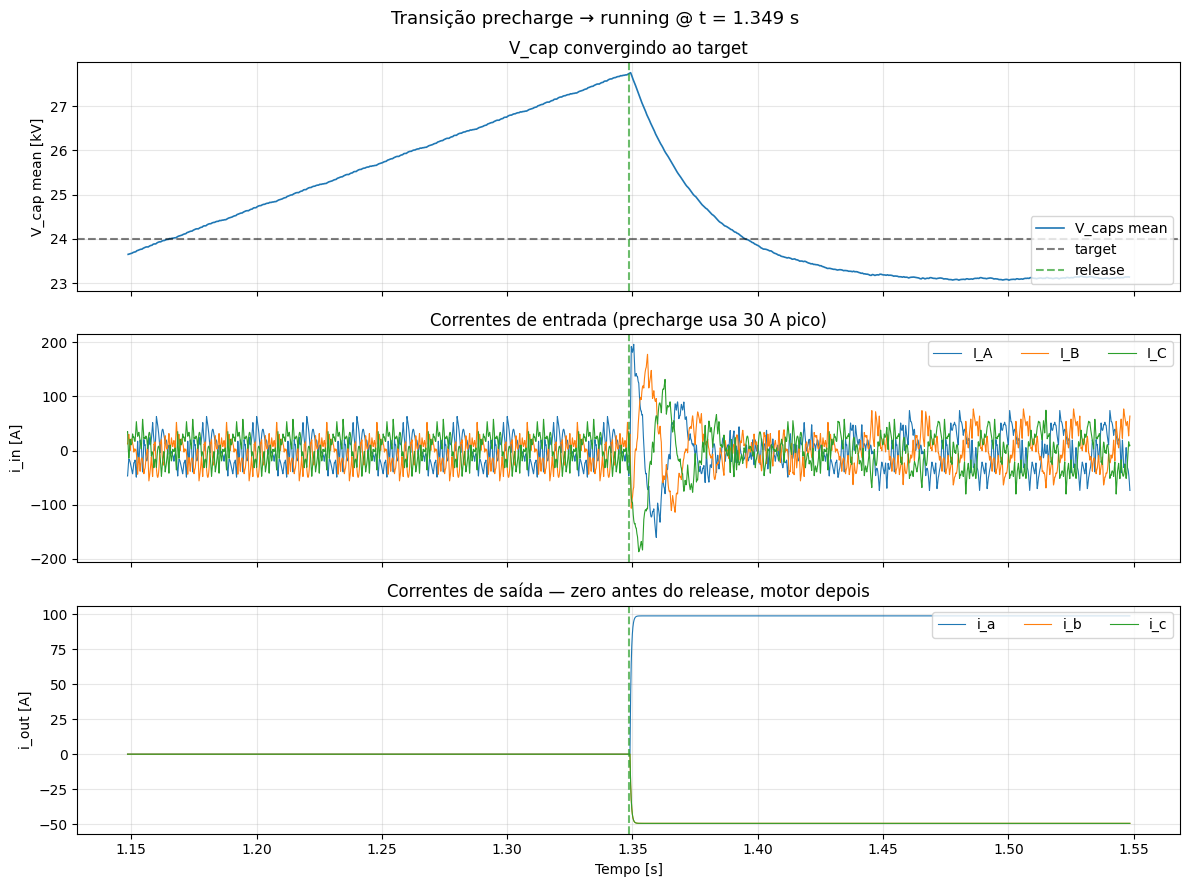

In [6]:
t_rel = fsm.released_at
mask = (result.t >= t_rel - 0.2) & (result.t <= t_rel + 0.2)
mask_caps = (t_caps >= t_rel - 0.2) & (t_caps <= t_rel + 0.2)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle(f"Transição precharge → running @ t = {t_rel:.3f} s",
                fontsize=13)

axes[0].plot(t_caps[mask_caps], v_mean[mask_caps]/1000, "C0",
                linewidth=1.2, label="V_caps mean")
axes[0].axhline(target/1000, color="k", linestyle="--", alpha=0.5,
                label="target")
axes[0].axvline(t_rel, color="C2", linestyle="--", alpha=0.7,
                label="release")
axes[0].set_ylabel("V_cap mean [kV]")
axes[0].set_title("V_cap convergindo ao target")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

axes[1].plot(result.t[mask], result.i_a_in[mask], "C0", linewidth=0.8, label="I_A")
axes[1].plot(result.t[mask], result.i_b_in[mask], "C1", linewidth=0.8, label="I_B")
axes[1].plot(result.t[mask], result.i_c_in[mask], "C2", linewidth=0.8, label="I_C")
axes[1].axvline(t_rel, color="C2", linestyle="--", alpha=0.7)
axes[1].set_ylabel("i_in [A]")
axes[1].set_title(f"Correntes de entrada (precharge usa {precharge_cfg.i_d_in_precharge:.0f} A pico)")
axes[1].legend(loc="upper right", ncol=3)
axes[1].grid(True, alpha=0.3)

axes[2].plot(result.t[mask], result.i_a_out[mask], "C0", linewidth=0.8, label="i_a")
axes[2].plot(result.t[mask], result.i_b_out[mask], "C1", linewidth=0.8, label="i_b")
axes[2].plot(result.t[mask], result.i_c_out[mask], "C2", linewidth=0.8, label="i_c")
axes[2].axvline(t_rel, color="C2", linestyle="--", alpha=0.7)
axes[2].set_ylabel("i_out [A]")
axes[2].set_xlabel("Tempo [s]")
axes[2].set_title("Correntes de saída — zero antes do release, motor depois")
axes[2].legend(loc="upper right", ncol=3)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8.5 — Figura 3: as tensões individuais dos 9 capacitores

Verifica que **todos os 9 caps carregam juntos** (o cost function
mantém o balanço relativo durante a precharge) e ficam balanceados
no steady-state.


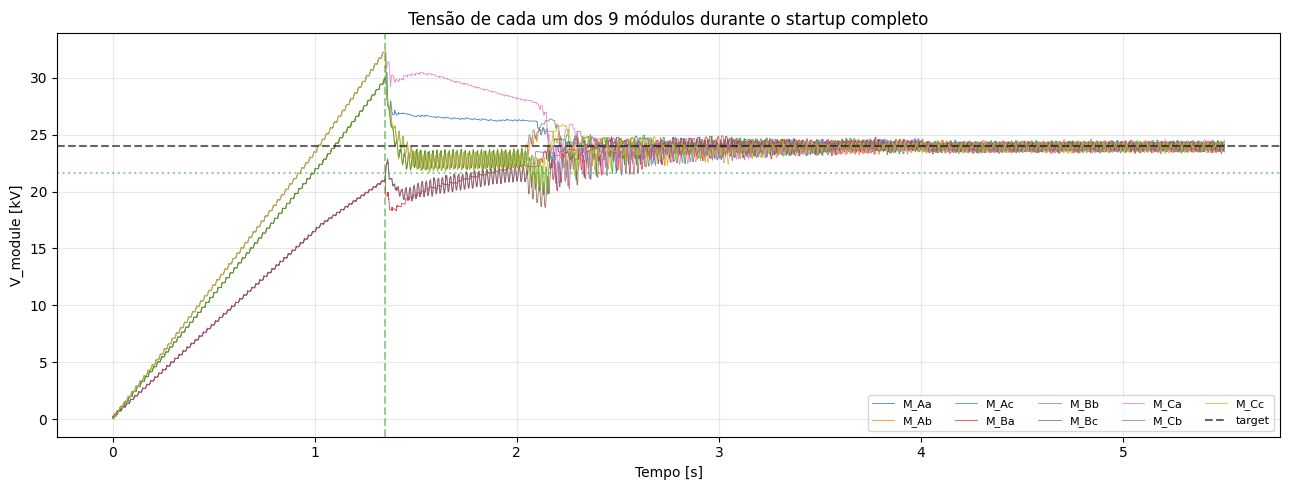

In [7]:
fig, ax = plt.subplots(figsize=(13, 5))
labels = [f"M_{ipl}{opl}" for ipl in "ABC" for opl in "abc"]
for k in range(9):
    ax.plot(t_caps, v_hist[:, k]/1000, linewidth=0.6, alpha=0.85, label=labels[k])
ax.axhline(target/1000, color="k", linestyle="--", alpha=0.6, label="target")
ax.axhline(
    precharge_cfg.v_cap_release_threshold_frac*target/1000,
    color="C2", linestyle=":", alpha=0.5,
)
ax.axvline(fsm.released_at, color="C2", linestyle="--", alpha=0.5)
ax.set_xlabel("Tempo [s]")
ax.set_ylabel("V_module [kV]")
ax.set_title("Tensão de cada um dos 9 módulos durante o startup completo")
ax.legend(loc="lower right", ncol=5, fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 8.6 — Resumo

A FSM de pré-carga funciona como um circuito de partida real:

| Fase | i_in | i_out | cap-PI | V_cap_mean |
|---|---:|---:|---|---|
| **PRECHARGE** (t < 1.05 s) | 30 A | 0 | off | rampa 0 → 21.6 kV |
| **STABILIZING** (1.05 → 1.35 s) | 30 A | 0 | off | mantém ~21.6 kV |
| **RUNNING** (t ≥ 1.35 s) | ditado por cap-PI | **rampa motor** | on | ajusta para 24 kV |

* **Tempo de carga**: ~1 s para chegar a 90 % do nominal a 30 A.
  Pode ser acelerado aumentando `i_d_in_precharge` (custo: stress
  inicial maior).
* **Não há corrente de inrush** — i_in é limitada à referência de
  30 A durante toda a precharge.
* **Após o release**, o cap-PI corrige os últimos ~10 % e mantém
  os caps em 24 kV ± 0.1 %.
* **A partida do motor é segura** porque os caps já estão no
  nominal — o DBPC tem toda a faixa de modulação disponível.

Esta sequência é o que se implementa em controladores reais
(Siemens, ABB, etc.) para drives baseados em conversores matriciais.
